# 64 - Image Transforms

**Section:** Convolution and transformations | **Prereqs:** `Convolution and transformations/Transpose_Conv.ipynb` | **Next:** `Convolution and transformations/Creating_Custom_DataLoaders.ipynb`

`torchvision.transforms` is a pipeline of image operations, chained with
`T.Compose([...])` and applied lazily by the Dataset as each sample is read.

**Two different jobs, often confused**

*Preparation* - applied to train, validation and test alike:
`ToTensor()` (also scales 0-255 to 0-1 and reorders to CxHxW), `Resize`,
`Normalize`, `Grayscale`.

*Augmentation* - applied to the **training set only**, and randomly re-rolled
every epoch: `RandomHorizontalFlip`, `RandomCrop`, `RandomRotation`,
`ColorJitter`. Each epoch the model sees a slightly different version of every
image, which is `More on Data/Handeling_Unbalanced_Data_noise_augmentation.ipynb`
generalised - and one of the most effective regularisers there is for vision.

**Two rules**
- `ToTensor()` goes near the start (most transforms need a PIL image or a tensor,
  not a numpy array) and `Normalize` last, since it needs a tensor.
- Augment only the training split. Random flips on your test set make the score
  noise, and any random transform on test data makes your evaluation
  irreproducible.

**Augmentations must preserve the label.** Flipping a cat horizontally is still a
cat; flipping a 2 vertically is not a 2. Pick transforms that match the data.

In [23]:
import numpy as np
import torch

import torchvision
import torchvision.transforms as T

import matplotlib.pyplot as plt

In [24]:
# CIFAR-10: 60000 colour images, 32x32, 10 classes. The standard next step up
# from MNIST - colour, textures, and objects rather than strokes.
dataset = torchvision.datasets.CIFAR10(root='cifar10', download=True)

In [25]:
# (50000, 32, 32, 3): NUMPY layout, height-width-channels. PyTorch wants
# channels first - ToTensor() does that conversion.
dataset.data.shape

(50000, 32, 32, 3)

In [26]:
len(dataset.targets)

50000

In [27]:
# The class names, in label order.
dataset.classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

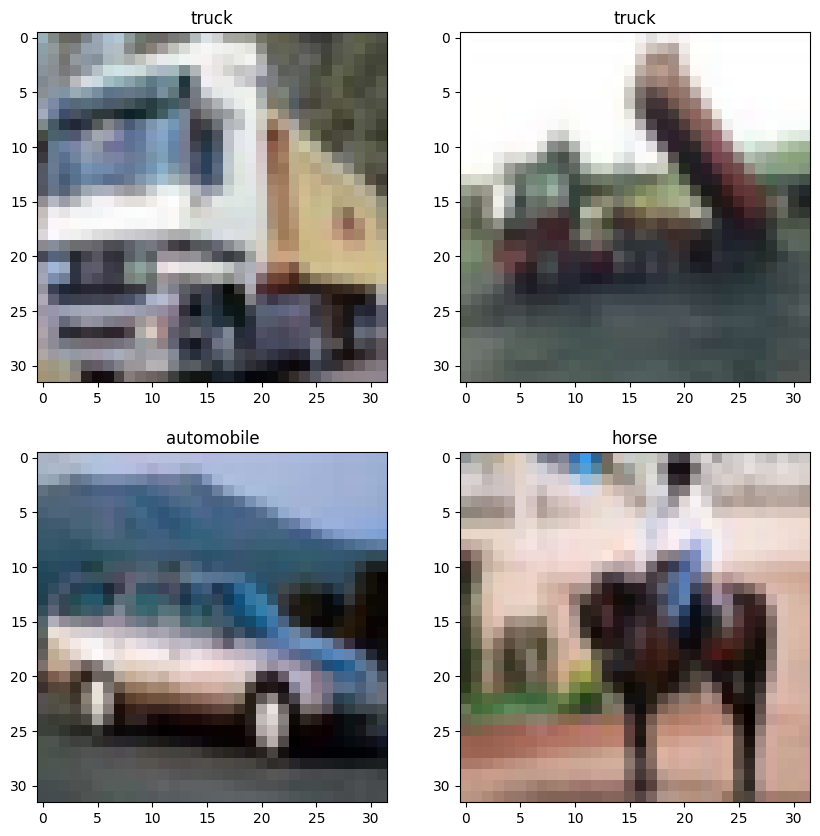

In [28]:
# Four samples. At 32x32 CIFAR is genuinely hard to read by eye, which is a
# useful calibration for the accuracies later in the course.
fig,ax = plt.subplots(2,2, figsize=(10,10))

ax[0,0].imshow(dataset.data[1,:,:,:])
ax[0,0].set_title(dataset.classes[dataset.targets[1]]);

ax[0,1].imshow(dataset.data[2,:,:,:])
ax[0,1].set_title(dataset.classes[dataset.targets[2]]);

ax[1,0].imshow(dataset.data[4,:,:,:])
ax[1,0].set_title(dataset.classes[dataset.targets[4]]);

ax[1,1].imshow(dataset.data[11,:,:,:])
ax[1,1].set_title(dataset.classes[dataset.targets[11]]);

## Transformations

In [32]:
# A Compose pipeline:
#   ToTensor()  - to CxHxW float in [0,1],
#   Resize(128) - upscale 4x,
#   Grayscale   - collapse 3 channels to 1.
# Transforms run in the order listed, and each one's output must be a type the
# next accepts - the usual source of errors here.
Ts = T.Compose([T.ToTensor(),
               T.Resize(32*4),
               T.Grayscale(num_output_channels=1)])



In [36]:
# Assigning to dataset.transform makes the pipeline run lazily, per sample, as
# the DataLoader reads it. dataset.data stays raw - which is why the shape
# printed here is unchanged.
dataset.transform = Ts

dataset.data[1,:,:,:].shape # Not trasformed

(32, 32, 3)

In [53]:
# Applying the pipeline manually to one image, to see the effect.
transformed_data = Ts(dataset.data[0,:,:,:])

In [54]:
# (1,128,128): one channel after Grayscale, 128 after Resize, channels-first
# after ToTensor.
transformed_data.shape

torch.Size([1, 128, 128])

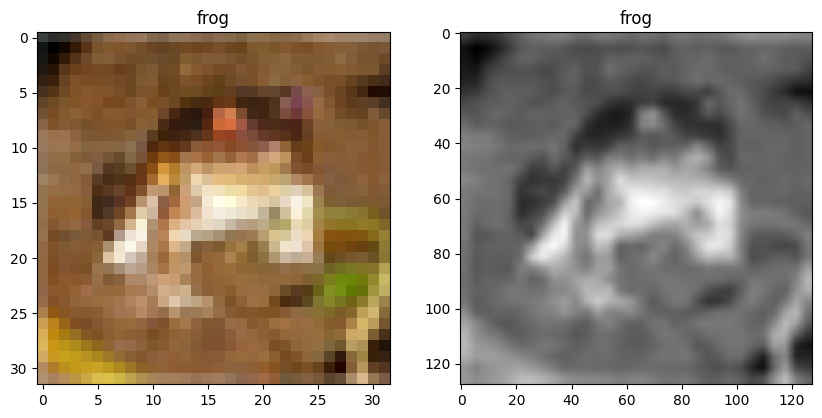

In [55]:
# Original vs transformed. squeeze() drops the channel axis so matplotlib can
# draw it as a 2-D greyscale array.
fig,ax = plt.subplots(1,2, figsize=(10,10))

ax[0].imshow(dataset.data[0,:,:,:])
ax[0].set_title(dataset.classes[dataset.targets[0]]);

ax[1].imshow(transformed_data.squeeze(), cmap='gray')
ax[1].set_title(dataset.classes[dataset.targets[0]]);



In [ ]:
## There are alot of transfroms : https://docs.pytorch.org/vision/0.8/transforms.html

In [42]:
transformed_data.squeeze().shape

torch.Size([128, 128])